In [1]:
# Cell 1: Import libraries
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Cell 2: Create sample customer feedback dataset
data = {
    "product": [
        "Smart Bottle","Smart Bottle","Smart Bottle","Smart Bottle",
        "Wireless Earbuds","Wireless Earbuds","Wireless Earbuds","Wireless Earbuds",
        "Travel Backpack","Travel Backpack","Travel Backpack","Travel Backpack",
        "Smart Bottle","Wireless Earbuds","Travel Backpack"
    ],
    "feedback": [
        "The bottle quality is excellent and keeps water cold for many hours",
        "Good product but the price is too high",
        "The packaging was damaged when I received the bottle",
        "Easy to use and the design looks great",
        "Sound quality is excellent and the earbuds are comfortable",
        "Battery life is very poor and needs improvement",
        "The price is reasonable but the packaging is not good",
        "Very easy to use and connection is fast",
        "The backpack has excellent quality and enough space",
        "The zipper is weak and the packaging could be better",
        "Comfortable bag but the price is expensive",
        "The design is good but the material quality can improve",
        "The bottle is useful but the cap is difficult to open",
        "Great sound quality but battery performance is disappointing",
        "Good design and comfortable, but the price should be lower"
    ],
    "sentiment": [
        "positive","negative","negative","positive",
        "positive","negative","negative","positive",
        "positive","negative","negative","positive",
        "negative","negative","negative"
    ]
}

df = pd.DataFrame(data)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (15, 3)


,product,feedback,sentiment
0,Smart Bottle,The bottle quality is excellent and keeps wate...,positive
1,Smart Bottle,Good product but the price is too high,negative
2,Smart Bottle,The packaging was damaged when I received the ...,negative
3,Smart Bottle,Easy to use and the design looks great,positive
4,Wireless Earbuds,Sound quality is excellent and the earbuds are...,positive


In [3]:
# Cell 3: Basic dataset inspection
print("Number of feedback records:", len(df))
print("\nProducts:")
print(df["product"].value_counts())

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

Number of feedback records: 15

Products:
product
Smart Bottle        5
Wireless Earbuds    5
Travel Backpack     5
Name: count, dtype: int64

Sentiment distribution:
sentiment
negative    9
positive    6
Name: count, dtype: int64

Missing values:
product      0
feedback     0
sentiment    0
dtype: int64


In [4]:
# Cell 4: Text preprocessing
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["clean_feedback"] = df["feedback"].apply(clean_text)

df[["feedback", "clean_feedback"]].head(10)

,feedback,clean_feedback
0,The bottle quality is excellent and keeps wate...,bottle quality excellent keeps water cold many...
1,Good product but the price is too high,good product price high
2,The packaging was damaged when I received the ...,packaging damaged received bottle
3,Easy to use and the design looks great,easy use design looks great
4,Sound quality is excellent and the earbuds are...,sound quality excellent earbuds comfortable
5,Battery life is very poor and needs improvement,battery life poor needs improvement
6,The price is reasonable but the packaging is n...,price reasonable packaging good
7,Very easy to use and connection is fast,easy use connection fast
8,The backpack has excellent quality and enough ...,backpack excellent quality enough space
9,The zipper is weak and the packaging could be ...,zipper weak packaging could better


In [5]:
# Cell 5: Convert text into TF-IDF features
X = df["clean_feedback"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training features:", X_train_tfidf.shape)
print("Testing features:", X_test_tfidf.shape)

Training features: (11, 84)
Testing features: (4, 84)


In [6]:
# Cell 6: Train sentiment model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Model Accuracy: 50.00%

Classification Report:
              precision    recall  f1-score   support

    negative       0.50      1.00      0.67         2
    positive       0.00      0.00      0.00         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4



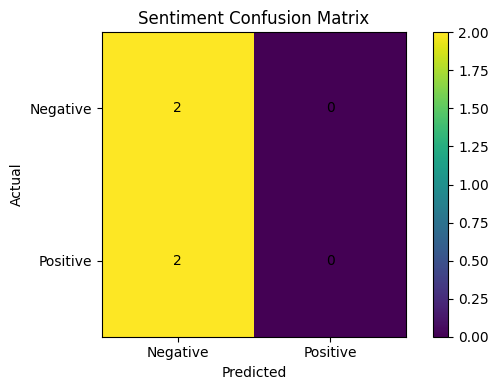

In [7]:
# Cell 7: Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=["negative", "positive"])

plt.figure(figsize=(6, 4))
plt.imshow(cm)
plt.title("Sentiment Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

In [8]:
# Cell 8: Predict sentiment for new customer feedback
def predict_sentiment(feedback):
    cleaned = clean_text(feedback)
    features = tfidf.transform([cleaned])
    prediction = model.predict(features)[0]
    probabilities = model.predict_proba(features)[0]
    confidence = max(probabilities)
    return prediction, confidence

test_feedback = [
    "The product is excellent and very easy to use",
    "The quality is poor and the price is too expensive",
    "I really like the design and packaging"
]

for text in test_feedback:
    sentiment, confidence = predict_sentiment(text)
    print(f"Feedback: {text}")
    print(f"Sentiment: {sentiment.upper()} | Confidence: {confidence:.2%}\n")

Feedback: The product is excellent and very easy to use
Sentiment: NEGATIVE | Confidence: 52.99%

Feedback: The quality is poor and the price is too expensive
Sentiment: NEGATIVE | Confidence: 68.62%

Feedback: I really like the design and packaging
Sentiment: NEGATIVE | Confidence: 66.31%



In [9]:
# Cell 9: Aspect-based keyword analysis
aspects = {
    "Quality": ["quality", "material", "weak"],
    "Pricing": ["price", "expensive", "cost", "reasonable"],
    "Packaging": ["packaging", "package", "damaged"],
    "Usability": ["use", "easy", "difficult", "comfortable"],
    "Battery": ["battery", "charging"],
    "Design": ["design"],
    "Sound": ["sound", "audio"],
    "Space": ["space"]
}

def find_aspects(text):
    text = text.lower()
    found = []
    for aspect, keywords in aspects.items():
        if any(re.search(r"\b" + re.escape(word) + r"\b", text) for word in keywords):
            found.append(aspect)
    return found

df["aspects"] = df["feedback"].apply(find_aspects)

aspect_rows = []
for _, row in df.iterrows():
    for aspect in row["aspects"]:
        aspect_rows.append({
            "product": row["product"],
            "aspect": aspect,
            "sentiment": row["sentiment"],
            "feedback": row["feedback"]
        })

aspect_df = pd.DataFrame(aspect_rows)

print("Aspect analysis:")
display(aspect_df.head(15))

Aspect analysis:


,product,aspect,sentiment,feedback
0,Smart Bottle,Quality,positive,The bottle quality is excellent and keeps wate...
1,Smart Bottle,Pricing,negative,Good product but the price is too high
2,Smart Bottle,Packaging,negative,The packaging was damaged when I received the ...
3,Smart Bottle,Usability,positive,Easy to use and the design looks great
4,Smart Bottle,Design,positive,Easy to use and the design looks great
5,Wireless Earbuds,Quality,positive,Sound quality is excellent and the earbuds are...
6,Wireless Earbuds,Usability,positive,Sound quality is excellent and the earbuds are...
7,Wireless Earbuds,Sound,positive,Sound quality is excellent and the earbuds are...
8,Wireless Earbuds,Battery,negative,Battery life is very poor and needs improvement
9,Wireless Earbuds,Pricing,negative,The price is reasonable but the packaging is n...


In [10]:
# Cell 10: Find negative feedback areas
negative_aspects = (
    aspect_df[aspect_df["sentiment"] == "negative"]
    .groupby("aspect")
    .size()
    .sort_values(ascending=False)
)

print("Negative feedback by product aspect:")
display(negative_aspects.to_frame("negative_feedback_count"))

Negative feedback by product aspect:


,negative_feedback_count
aspect,
Pricing,4
Usability,3
Packaging,3
Quality,2
Battery,2
Design,1
Sound,1


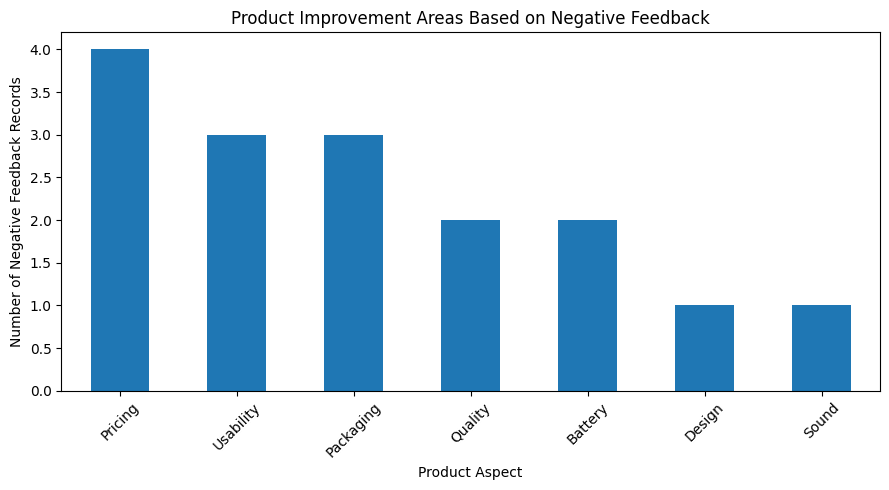

In [11]:
# Cell 11: Visualize improvement areas
plt.figure(figsize=(9, 5))
negative_aspects.plot(kind="bar")
plt.title("Product Improvement Areas Based on Negative Feedback")
plt.xlabel("Product Aspect")
plt.ylabel("Number of Negative Feedback Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
# Cell 12: Business insights
product_summary = (
    df.groupby(["product", "sentiment"])
      .size()
      .unstack(fill_value=0)
)

product_summary["total_feedback"] = product_summary.sum(axis=1)

if "positive" not in product_summary.columns:
    product_summary["positive"] = 0
if "negative" not in product_summary.columns:
    product_summary["negative"] = 0

product_summary["positive_rate"] = (
    product_summary["positive"] / product_summary["total_feedback"] * 100
).round(1)

display(product_summary.sort_values("positive_rate", ascending=False))

print("\nBUSINESS INSIGHTS")
print("-" * 50)

best_product = product_summary["positive_rate"].idxmax()
needs_attention = product_summary["negative"].idxmax()

print(f"1. Product with highest positive feedback rate: {best_product}")
print(f"2. Product needing the most attention: {needs_attention}")

if len(negative_aspects) > 0:
    top_issue = negative_aspects.index[0]
    print(f"3. Most frequently mentioned negative aspect: {top_issue}")

print("4. Management should prioritize aspects with the highest negative feedback.")
print("5. Positive feedback areas can be used in marketing and product positioning.")

sentiment,negative,positive,total_feedback,positive_rate
product,,,,
Smart Bottle,3,2,5,40.0
Travel Backpack,3,2,5,40.0
Wireless Earbuds,3,2,5,40.0



BUSINESS INSIGHTS
--------------------------------------------------
1. Product with highest positive feedback rate: Smart Bottle
2. Product needing the most attention: Smart Bottle
3. Most frequently mentioned negative aspect: Pricing
4. Management should prioritize aspects with the highest negative feedback.
5. Positive feedback areas can be used in marketing and product positioning.


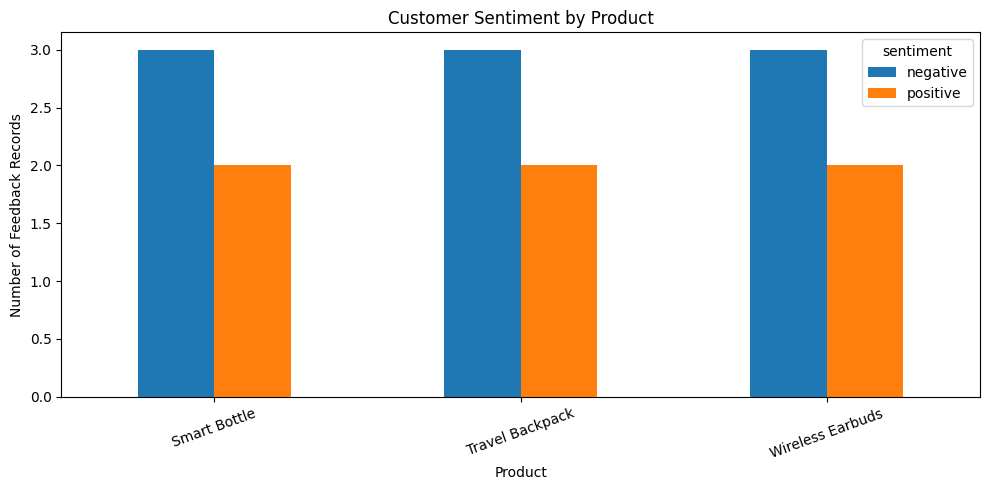

In [13]:
# Cell 13: Product sentiment chart
sentiment_by_product = pd.crosstab(df["product"], df["sentiment"])

sentiment_by_product.plot(kind="bar", figsize=(10, 5))
plt.title("Customer Sentiment by Product")
plt.xlabel("Product")
plt.ylabel("Number of Feedback Records")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [14]:
# Cell 14: Final analyzer
def analyze_feedback(feedback):
    sentiment, confidence = predict_sentiment(feedback)
    detected_aspects = find_aspects(feedback)

    negative_words = [
        "poor", "bad", "expensive", "weak", "difficult",
        "disappointing", "damaged", "problem", "slow"
    ]

    has_negative_words = any(
        re.search(r"\b" + re.escape(word) + r"\b", feedback.lower())
        for word in negative_words
    )

    if sentiment == "negative" or has_negative_words:
        if detected_aspects:
            recommendation = (
                "Management should review: " +
                ", ".join(detected_aspects) +
                " and consider product/service improvements."
            )
        else:
            recommendation = "Management should review this feedback and identify the underlying issue."
    else:
        recommendation = "The feedback is positive. Consider maintaining the current product strengths."

    return {
        "feedback": feedback,
        "sentiment": sentiment.upper(),
        "confidence": f"{confidence:.2%}",
        "detected_aspects": detected_aspects if detected_aspects else ["No specific aspect detected"],
        "recommendation": recommendation
    }

sample = analyze_feedback(
    "The earbuds sound great but the battery life is very poor and the price is expensive"
)

for key, value in sample.items():
    print(f"{key.title()}: {value}")

Feedback: The earbuds sound great but the battery life is very poor and the price is expensive
Sentiment: NEGATIVE
Confidence: 71.49%
Detected_Aspects: ['Pricing', 'Battery', 'Sound']
Recommendation: Management should review: Pricing, Battery, Sound and consider product/service improvements.


In [15]:
# Cell 15: Export analysis results
output_file = "customer_feedback_analysis.csv"

export_df = df.copy()
export_df["aspects"] = export_df["aspects"].apply(lambda x: ", ".join(x))

export_df.to_csv(output_file, index=False)

print(f"Analysis results saved to: {output_file}")

Analysis results saved to: customer_feedback_analysis.csv
